# Lab 4: Denoising and Matrix Completion with Nuclear Norm

**Students**:

- Julius Pfingsten, 2256430
- Viktoriia Vlasenko, 2088928

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import urllib
import PIL
from math import ceil

rnd_state = np.random.RandomState(12)

## Exercise 1: Image Denoising
Let $\bar{x} \in \mathbb{R}^{n \times m}$ be an image of $n \times m$ pixels and let $y \in \mathbb{R}^{n \times m}$ be the same image but with noise i.e.
$$
y = \bar{x} + \epsilon
$$


In [40]:
url = "https://github.com/gpeyre/numerical-tours/blob/master/python/nt_toolbox/data/flowers.png?raw=true"
x_bar = PIL.Image.open(urllib.request.urlopen(url)).convert('L') # real image

x_bar = np.asarray(x_bar).astype('float32')

n, m = x_bar.shape

y = x_bar + 50 * rnd_state.randn(n, m)

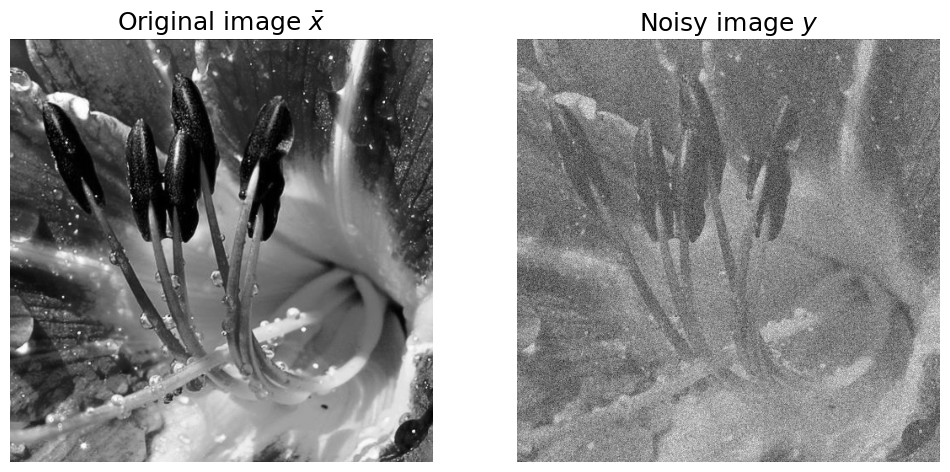

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.set_title("Original image $\\bar{x}$", fontsize=18)
ax2.set_title("Noisy image $y$", fontsize=18)

ax1.imshow(x_bar, cmap='gray')
ax2.imshow(y, cmap='gray')

ax1.set_axis_off()
ax2.set_axis_off()



Let us consider the following denoising problem
$$
\min\limits_{x \in \mathbb{R}^{n \times m}} \frac{1}{2}\| x - y\|^2 + \lambda \| D x \|_{2,1}
$$
with $\lambda > 0$ e $D : \mathbb{R}^{d \times d} \to (\mathbb{R}^{2})^{d \times d}$ the discrete gradient defined as follows
$$
(D x)_{i, j} = ((D_1 x)_{i, j}, (D_2 x)_{i, j} )
$$
with
$$
(D_1 x)_{i, j} = \left\{
  \begin{array}{ll}
    x_{i + 1, j} - x_{i, j} & 1 \leq i \leq d - 1\\
    0 & i= d
   \end{array}
  \right. \qquad (D_2 x)_{i, j} = \left\{
  \begin{array}{ll}
    x_{i, j + 1} - x_{i, j} & 1 \leq j \leq d - 1\\
    0 & j= d
   \end{array}
  \right.
$$
Furthermore
$$
\| x \|_{2,1} = \sum\limits_{i, j = 1}^d \| x_{i, j}\|_2 \qquad x_{i, j} \in \mathbb{R}^2
$$



Let us define a function `disc_grad(x)` that given an image $x$ computes the discrete gradient and returns the couple $(D_1 x, D_2 x)$


In [42]:
def disc_grad(x):
  grad = np.zeros([*x.shape, 2])
  # TODO: implement the discrete gradient of x
  # hint: use np.diff and be careful with the dimensions
  grad[:-1, :, 0] = np.diff(x, axis=0)
  grad[:, :-1, 1] = np.diff(x, axis=1)
  return grad

Having defined the discrete gradient, we can implement the target function as follows

In [43]:
def f(x, lam):
  # TODO: implement the function
  return 1/2 * np.linalg.norm(x - y)**2 + lam * np.sum(np.linalg.norm(disc_grad(x), axis=2))

Now we can compute $D \bar{x}$ and plot it

Text(0.5, 1.0, 'd/dy')

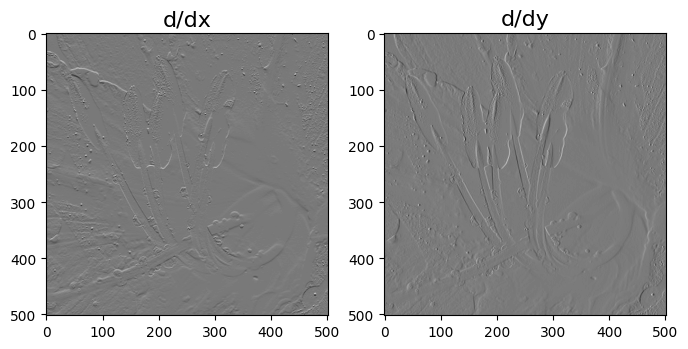

In [44]:
grad =  disc_grad(x_bar)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(grad[:, :, 0], cmap='gray')
ax1.set_title("d/dx", fontsize=16)
ax2.imshow(grad[:, :, 1], cmap='gray')
ax2.set_title("d/dy", fontsize=16)


Note that we cannot directly use Forward-Backward since the prox of the total variation is not in closed form.
Let us consider the dual problem
$$
\min\limits_{u \in (\mathbb{R}^2)^{n \times m}} \frac{1}{2} \|y - D^* u \|^2 - \frac{1}{2} \| y \|^2 + \iota_{B_\lambda(0)^{n \times m} (u)}
$$
where $B_\lambda(0)$ is the ball in $\mathbb{R}^2$ centered at $0$ and
$$
D^* = - \text{div} : (\mathbb{R}^2)^{n \times m} \to \mathbb{R}^{n \times m}
$$

defined as follows
$$
(\text{div}(u))_{i,j} = (\text{div}(u^{(1)}, u^{(2)}))_{i,j} = \left\{
  \begin{array}{ll}
    u^{(1)}_{i, j} - u^{(1)}_{i - 1, j}  & 1 < i < n\\
    u^{(1)}_{1, j}  & i = 1\\
    - u^{(1)}_{n - 1, j} & i = n
  \end{array}
  \right.  + \left\{
  \begin{array}{ll}
    u^{(2)}_{i, j} - u^{(2)}_{i, j-1}  & 1 < j < m\\
    u^{(2)}_{i, 1}  & j = 1\\
    - u^{(2)}_{i, m - 1} & j = m
  \end{array}
  \right.
$$


Let us now define a function `grad_star(u)` that given a vector field `u` returns $- \text{div}(u)$

In [45]:
def grad_star(u):
  div = np.zeros((u.shape[0], u.shape[1]))
  div[0, :] += u[0, :, 0]
  div[1:-1, :] += np.diff(u[:-1, :, 0], axis=0)
  div[-1, :] = -u[-2, :, 0]

  div[:, 0] += u[:, 0, 1]
  div[:, 1:-1] += np.diff(u[:, :-1, 1], axis=1)
  div[:, -1] = -u[:, -2, 1]
  return -div

The target function in the dual is therefore

In [46]:
def f_dual(u):
  # TODO: return the value of the objective function of the dual problem
  return 1/2 * np.linalg.norm(y - grad_star(u))**2 - 1/2 * np.linalg.norm(y)**2

We can therefore solve the problem using Forward-Backward in the dual.
The iteration can be written as follows: $u_0=0, \ x_0=y$ and for every $k\geq0$
\begin{align*}
u^{(k + 1)}_{i, j} &= P_{B_\lambda(0)}(u^{(k)}_{i, j} + \gamma (D x^{(k)})_{i, j} ) \\
x^{(k+1)} &= y - D^*u^{(k+1)}
\end{align*}
with $\gamma < 2/L$. Note that
$
L = \| D D^* \| \leq 8.
$

$P_{B_\lambda(0)}$ is the projection operator onto the ball in $\mathbb{R}^2$ of radius $\lambda$ centered at $0$ i.e.
$$
P_{B_\lambda(0)^{n \times m}}(u) = (P_{B_\lambda(0)}(u_{i, j}))_{i, j}, \qquad P_{B_\lambda(0)}(u_{i, j}) = \left\{
\begin{array}{ll}
  u_{i, j} & \text{ if }\|u_{i, j}\| \leq \lambda\\
  \frac{u_{i, j}}{\|u_{i,j}\|_2} &  \text{ otherwise }
\end{array}
  \right.
$$

Let us implement the operator with the function `project_B(x,\lambda)`



In [47]:
def project_B(u, lam):
  # TODO: implement the projection
  norms_u = np.linalg.norm(u, axis=2, keepdims=True)
  return np.where(norms_u <= lam, u, lam * u / norms_u)

Let us implement the function
```
dual_fb(u0, gamma, lam, max_iter)
```
where:
- `u0`: initial guess (in the dual)
- `gamma`: stepsize
- `lam`: regularization parameter
- `max_iter`: number of iterations

In [48]:
def dual_fb(u0, gamma, lam, max_iter):
  x_iters, u_iters = np.empty((max_iter + 1 , u0.shape[0], u0.shape[1])), np.empty((max_iter + 1 , u0.shape[0], u0.shape[1], u0.shape[2]))
  f_vals, f_dual_vals = np.empty(max_iter + 1), np.empty(max_iter+ 1)

  u = u0.copy()
  x = y

  x_iters[0] = x.copy()
  u_iters[0] = u.copy()
  f_vals[0] = f(y - grad_star(u), lam)
  f_dual_vals[0] = f_dual(u)

  for k in range(max_iter):

    # TODO: implement the FB iteration for the dual problem
    u = project_B(u + gamma * disc_grad(x), lam)
    x = y - grad_star(u)

    x_iters[k + 1] = x.copy()
    u_iters[k + 1] = u.copy()
    f_vals[k + 1] = f(x, lam)
    f_dual_vals[k + 1] = f_dual(u)

  return x_iters, u_iters, f_vals, f_dual_vals

Let us now run the algorithm

In [49]:
u0 = np.zeros((n, m, 2))
# TODO: choose a value for the step-size
gamma = 0.2

lam = 45.0
max_iter = 1000

# TODO: Run the implemented algorithm
x_iters, u_iters, f_vals, f_dual_vals = dual_fb(u0, gamma, lam, max_iter)

/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_42902/3666338823.py:4: RuntimeWarning: invalid value encountered in divide
  return np.where(norms_u <= lam, u, lam * u / norms_u)


Let us plot $\Phi$ and $-\Psi$ on the computed iterates

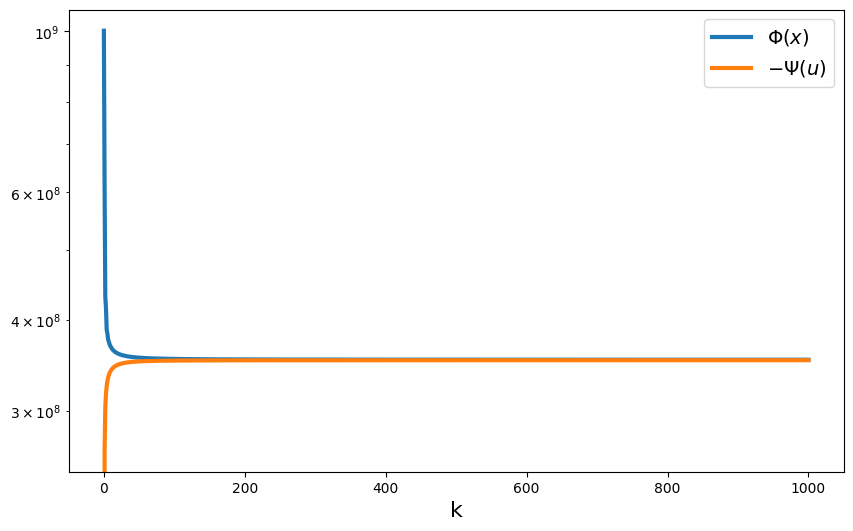

In [50]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(max_iter + 1), f_vals, '-', lw=3, label="$\Phi(x)$")
ax.plot(range(max_iter + 1), -f_dual_vals, '-', lw=3, label="$-\Psi(u)$")
ax.set_yscale('log')
ax.set_xlabel("k", fontsize=16)
ax.legend(fontsize=14)

Let us also plot the duality gap function

Text(0.5, 1.0, 'Duality Gap Function')

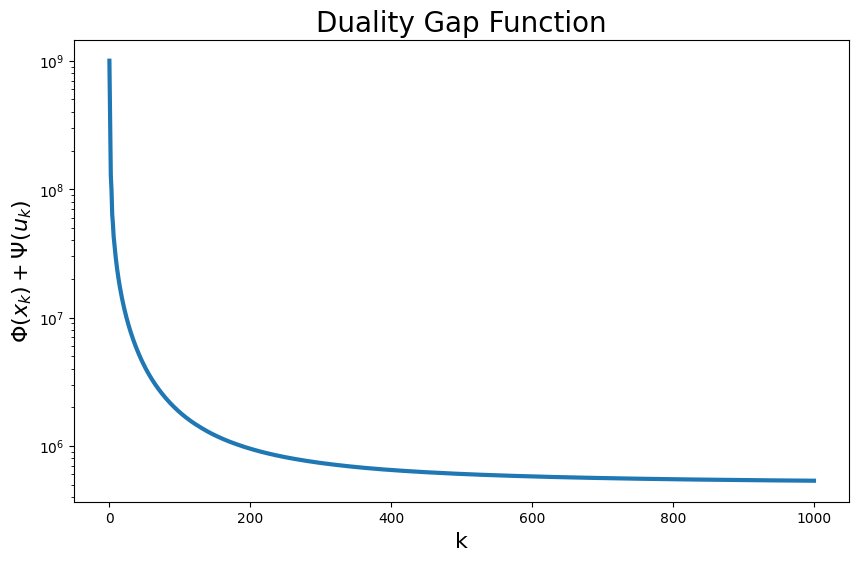

In [51]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(max_iter + 1), f_vals + f_dual_vals, '-', lw=3)
ax.set_yscale('log')
ax.set_xlabel("k", fontsize=16)
ax.set_ylabel("$\Phi(x_k) + \Psi(u_k)$", fontsize=16)
ax.set_title("Duality Gap Function", fontsize=20)

Let us also plot the reconstructed image

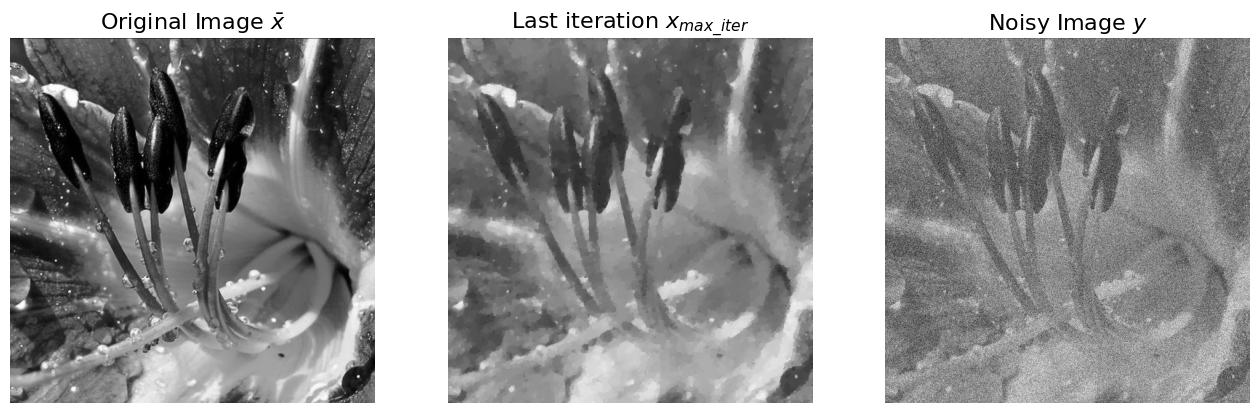

In [52]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 8))
ax1.imshow(x_bar, cmap='gray')
ax2.imshow(x_iters[-1], cmap='gray')
ax3.imshow(y, cmap='gray')

ax1.set_axis_off()
ax2.set_axis_off()
ax3.set_axis_off()

_ = ax1.set_title("Original Image $\\bar{x}$", fontsize=16)
_ = ax2.set_title("Last iteration $x_{max\_iter}$", fontsize=16)
_ = ax3.set_title("Noisy Image $y$", fontsize=16)


### FISTA in the dual
As seen in class and in the previous lab, the algorithm can be extended by including inertia.

We set $u^{(0)} = v^{(0)}$, $x^{(0)} = z^{(0)} = y - D^* u^{(0)}$ e $\gamma \leq 1/8.$

The iteration is therefore defined as follows
\begin{align*}
u^{(k + 1)} &= P_{B_\lambda(0)^{n \times m}}(v^{(k)} + \gamma D z^{(k)}) \\
x^{(k+1)} &= y - D^* u^{(k+1)} \\
v^{(k + 1)} &= u^{(k + 1)} + \beta_{k + 1} (u^{(k + 1)} - u^{(k)}) \\
z^{(k + 1)} &= x^{(k + 1)} + \beta_{k + 1} (x^{(k + 1)} - x^{(k)})
\end{align*}

where $\beta_k$ is the inertia parameter
$$
\beta_{k + 1} = \frac{t_k - 1}{t_{k + 1}}
$$

Let us now implement a function `beta(tk, k)` using one of the criteria seen in previous labs (e.g. Nesterov o Chambolle & Dossal).

This function takes as input $t_k$ and $k$ and returns $\beta_{k + 1}$ e $t_{k + 1}$.

In [53]:
alpha = 12

def beta(tk, k):
  # TODO: implement a scheme to compute the inertia parameter
  # using the Nesterov sequence
  t_next = (1 + np.sqrt(1 + 4 * tk**2)) / 2
  beta = (tk - 1) / t_next
  return beta, t_next

Let us implement a function
```
dual_fista(u0, beta, gamma, lam, max_iter)
```
Where:
- `u0`: initial guess (in the dual)
- `beta`: function that computes $\beta_{k + 1}$
- `gamma`: stepsize
- `lam`: regularization parameter
- `max_iter`: number of iterations

In [54]:
def dual_fista(u0, beta_func, gamma, lam, max_iter):
  x_iters, u_iters = np.empty((max_iter + 1, u0.shape[0], u0.shape[1])), np.empty((max_iter + 1, u0.shape[0], u0.shape[1], u0.shape[2]))
  f_vals, f_dual_vals = np.empty(max_iter + 1), np.empty(max_iter + 1)

  u = u0.copy()
  v = u.copy()
  x = y - grad_star(u)
  z = x.copy()

  tk = 1

  x_iters[0] = x.copy()
  u_iters[0] = u.copy()
  f_vals[0] = f(y - grad_star(u), lam)
  f_dual_vals[0] = f_dual(u)

  for k in range(max_iter):
    # TODO
    u_prev = u.copy()
    x_prev = x.copy()

    current_beta, tk_next = beta_func(tk, k)

    u = project_B(v + gamma * disc_grad(z), lam)
    x = y - grad_star(u)
    v = u + current_beta * (u - u_prev)
    z = x + current_beta * (x - x_prev)

    tk = tk_next

    x_iters[k + 1] = x.copy()
    u_iters[k + 1] = u.copy()
    f_vals[k + 1] = f(x, lam)
    f_dual_vals[k + 1] = f_dual(u)

  return x_iters, u_iters, f_vals, f_dual_vals

In [55]:
u0 = np.zeros((n, m, 2))

# TODO: choose a step-size
gamma = 0.1

max_iter = 1000

# TODO: Run the implemented algorithm
x_iters_fista, u_iters_fista, f_vals_fista, f_dual_vals_fista = dual_fista(u0, beta, gamma, lam, max_iter)

/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_42902/3666338823.py:4: RuntimeWarning: invalid value encountered in divide
  return np.where(norms_u <= lam, u, lam * u / norms_u)


Let us compare the duality gap function obtained with the one obtained from FB.

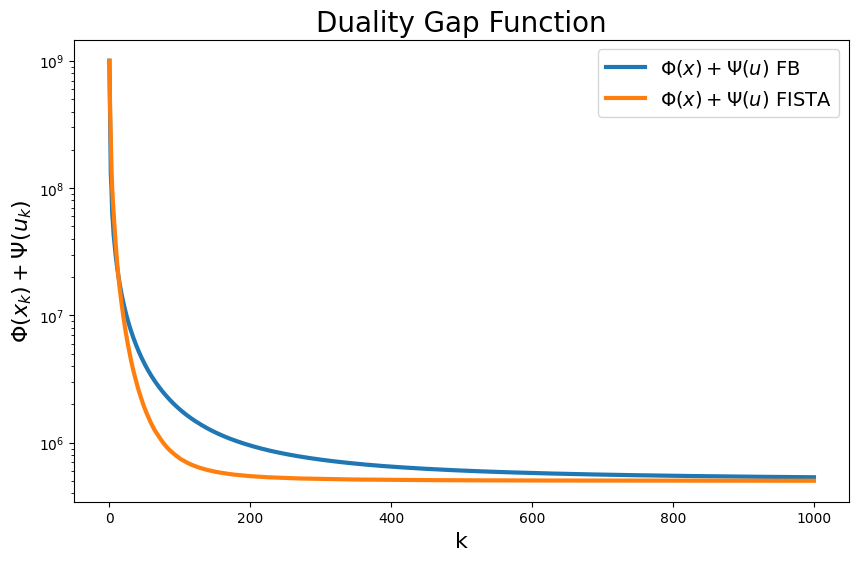

In [56]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(max_iter + 1), f_vals + f_dual_vals, '-', lw=3, label='$\Phi(x) + \Psi(u)$ FB')
ax.plot(range(max_iter + 1), f_vals_fista + f_dual_vals_fista, '-', lw=3, label='$\Phi(x) + \Psi(u)$ FISTA')
ax.set_yscale('log')
ax.set_xlabel("k", fontsize=16)
ax.set_ylabel("$\Phi(x_k) + \Psi(u_k)$", fontsize=16)
ax.set_title("Duality Gap Function", fontsize=20)
ax.legend(fontsize=14)

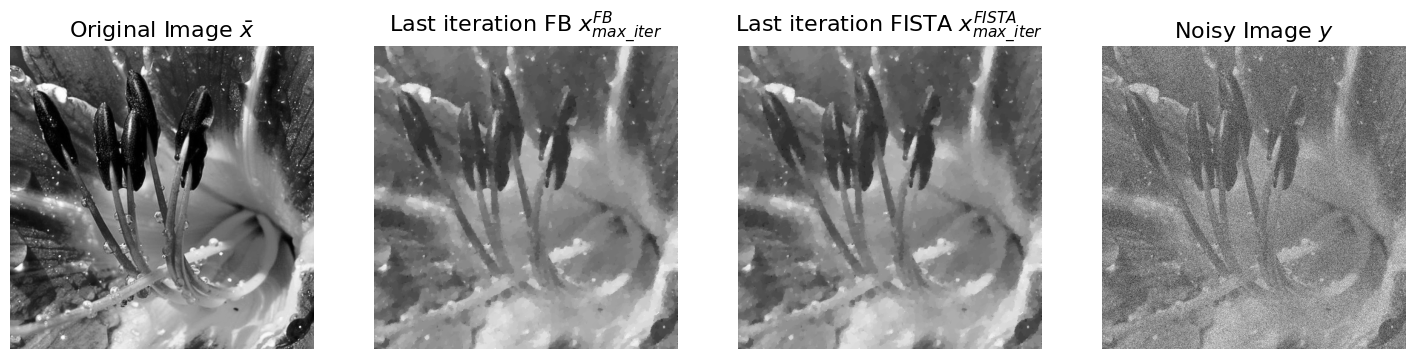

In [57]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(18, 8))
ax1.imshow(x_bar, cmap='gray')
ax2.imshow(x_iters[-1], cmap='gray')
ax3.imshow(x_iters_fista[-1], cmap='gray')
ax4.imshow(y, cmap='gray')

ax1.set_axis_off()
ax2.set_axis_off()
ax3.set_axis_off()
ax4.set_axis_off()

_ = ax1.set_title("Original Image $\\bar{x}$", fontsize=16)
_ = ax2.set_title("Last iteration FB $x^{FB}_{max\_{iter}}$", fontsize=16)
_ = ax3.set_title("Last iteration FISTA $x^{FISTA}_{max\_{iter}}$", fontsize=16)
_ = ax4.set_title("Noisy Image $y$", fontsize=16)


## Exercise 2: Matrix Completion with Nuclear Norm

The problem we address is the *matrix completion* problem, i.e. we want to recover a matrix $X \in \mathbb{R}^{d \times d}$ having available only a (noisy) subset of its entries $y \in \mathbb{R}^s$ with $s << d^2$.

The problem can be formalized as follows: let $I$ a subset of indices of cardinality $s$ and we define the (linear) operator $\Phi_I : \mathbb{R}^{d \times d} \to \mathbb{R}^s$ as follows
$$
\Phi_I X = (X_{i, j})_{(i, j) \in I}.
$$
In other words, given a matrix $X \in \mathbb{R}^{d \times d}$, the operator $\Phi_I$ constructs a vector whose entries are the entries of the matrix $X$ indicated by the set $I$.

In what follows, we will assume that the matrix $X$ we want to recover has rank $r << d$ (low rank). For example, let us consider the case:
- $d = 100$.
- $r = 10$.
- $s = d r \log d$

In [58]:
d = 100
r = 10

s = ceil(d * r * np.log(d))

# generate a random set of indices (without replacement)
I = rnd_state.permutation(d*d)
I = np.array([(idx // d, idx % d) for idx in I[:s]])#.reshape(-1, 2)

# Build a rank r matrix as a product of Gaussian vectors
X_star = rnd_state.randn(d, r) @ rnd_state.randn(r, d)

print(f"rank(X^*) = {np.linalg.matrix_rank(X_star)}")

rank(X^*) = 10


/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_42902/1728988995.py:11: RuntimeWarning: divide by zero encountered in matmul
  X_star = rnd_state.randn(d, r) @ rnd_state.randn(r, d)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_42902/1728988995.py:11: RuntimeWarning: overflow encountered in matmul
  X_star = rnd_state.randn(d, r) @ rnd_state.randn(r, d)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_42902/1728988995.py:11: RuntimeWarning: invalid value encountered in matmul
  X_star = rnd_state.randn(d, r) @ rnd_state.randn(r, d)


We can plot the singular values by computing the SVD.

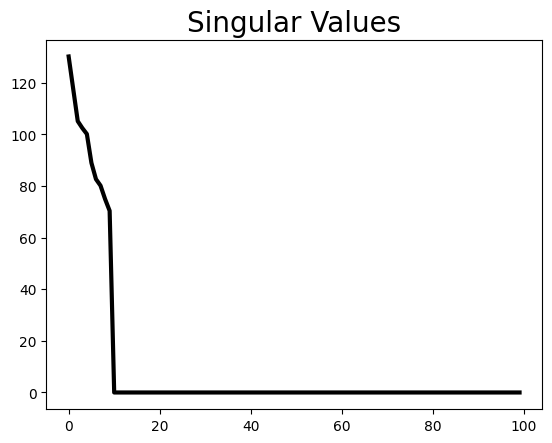

In [59]:
_, s_vals, _ = np.linalg.svd(X_star) # compute the singular values

fig, ax = plt.subplots()
ax.set_title("Singular Values", fontsize=20)
_ = ax.plot(s_vals, '-', lw=3, c='black')

Let us implement a function `phi(X)` that given a matrix $X \in \mathbb{R}^{d \times d}$ and returns a vector $\Phi_I X$ such that
$$
\Phi_I X = (X_{i, j})_{(i, j) \in I}.
$$
Furthermore, let us add noise obtaining
$$
y = \Phi_I X_* + \epsilon
$$
with $\epsilon \in \mathbb{R}^s$ Gaussian with standard deviation $0.1$.

In [60]:
def phi(X):
  return X[I[:, 0], I[:, 1]]

noise_std = 0.1
y = phi(X_star) + noise_std * rnd_state.randn(s)

Let us formalize the problem of recovering this matrix from the noisy observation $y$ as follows:
$$
X^* \in \arg\min\limits_{X \in \mathbb{R}^{d \times d}} F(X) := \underbrace{\frac{1}{2} \| \Phi_I X - y \|^2}_{=:f(x)} + \underbrace{\lambda \| X \|_*}_{=: g(x)},
$$
with $\lambda > 0$ regularization parameter that control the sparsity of the solution and $\|\cdot \|_*$ *nuclear norm* defined as follows:
$$
\| X \|_* = \sum\limits_{i = 1}^d \sigma_i(X),
$$
with $\sigma_i(X)$ singular values of $X$.

In [61]:
def F(X, lam):
  # in numpy we can specify the nuclear norm by passing the parameter ord='nuc' to np.linalg.norm
  # TODO: implement the function
  return 1/2 * np.linalg.norm(phi(X) - y)**2 + lam * np.linalg.norm(X, ord='nuc')

Let $X_0 \in \mathbb{R}^{d \times d}$ e $\gamma < 2/\| \Phi^* \Phi \| = 2$, let us consider the following iteration
$$
X_{k + 1} = \text{prox}_{\gamma \lambda \| \cdot \|_*}(X_k - \gamma \Phi_I^* (\Phi_I X_k - y ))
$$

Let $I = \{ (i_c, j_c) \}_{c=1}^s \in \mathbb{R}^s$ with $1 \leq i_c,j_c \leq d$, $\Phi^*_I$ is the operator that given an $x \in \mathbb{R}^s$, returns the matrix $\Phi^*_I(x)$ where
$$
[\Phi^*_I(x)]_{i_c, j_c} = x_c
$$

Let us implement this operator with the function `phi_star(x)` i.e. a function that takes as input an `x` and returns the matrix $\Phi^*_I(x)$.

In [62]:
def phi_star(y):
  X = np.zeros((d, d))
  X[I[:, 0], I[:, 1]] = y
  return X

Let us also implement the function `grad_f(x)` that given a matrix $X \in \mathbb{R}^{d \times d}$ computes the gradient $\nabla f(X)$.

In [63]:
def grad_f(x):
  # TODO: return the gradient of f at x
  return phi_star(phi(x) - y)

To compute the prox of the nuclear norm $\| X \|_*$ we can:
- compute the SVD of $X = U \Sigma V^\intercal$ with $\Sigma = \text{diag}(\sigma(X))$.
- compute the soft-thresholding of $\Sigma$ i.e.
$$
\text{prox}_{\gamma \lambda \| \cdot \|_*}(X) = U \text{diag}(\text{prox}_{\gamma \lambda \| \cdot \|_1}(\sigma(X)))V^\intercal
$$

Let us implement a function `prox(X, tau)` that performs exactly these operations i.e. given a matrix `X` and a parameter `tau`, returns
$$
\text{prox}_{\tau \| \cdot \|_*}(X)
$$
___
**Hint:** to compute the SVD in python we can use [np.linalg.svd](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html)
___

In [64]:
def prox(X, tau):
  # TODO: return the prox of the nuclear norm
  # singular value decomposition
  U, S, Vt = np.linalg.svd(X)
  S = np.diag(np.maximum(S - tau, 0))
  return U @ S @ Vt

Let us now define the function `fb` that implements the Forward-Backward algorithm. Specifically, the function will take the following parameters
```
fb(X0, lam, gamma, max_iter)
```
where:
- `X0` is the initial guess.
- `lam` is the regularization parameter $\lambda$.
- `gamma` is the step-size $\gamma$.
- `max_iter` is the number of iterations.

The function returns $X_{max_iter}$ (the last iterate) e the sequence $\|X_{k} - X^* \|_F$ for each iterate $X_k$.

In [65]:
def fb(X0, lam, gamma, max_iter):
  X = X0.copy()
  x_iters = np.empty((max_iter, d, d))
  x_iters[0] = X.copy()
  x_norms = np.zeros(max_iter)
  x_norms[0] = np.linalg.norm(X0.copy() - X_star, ord='fro')
  f_vals = [F(X, lam)]

  for k in range(1,max_iter):
    # TODO: implement the Forward-Backward iteration
    X = prox(X - gamma * grad_f(X), gamma * lam)

    x_iters[k] = X.copy()
    x_norms[k] = np.linalg.norm(X.copy() - X_star, ord='fro')
    f_vals.append(F(X, lam))

  return X, x_iters, x_norms, f_vals

Let us run the algorithm with stepsize $\gamma = 1.0$ e $\lambda = 0.1$.

In [66]:
gamma = 1.0
lam = 0.01
x0 = np.full((d, d), 10.0)

max_iter = 3000

# TODO: run Forward-backward
X, x_iters, x_norms, f_vals = fb(x0, lam, gamma, max_iter)

/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_42902/754532012.py:6: RuntimeWarning: divide by zero encountered in matmul
  return U @ S @ Vt
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_42902/754532012.py:6: RuntimeWarning: overflow encountered in matmul
  return U @ S @ Vt
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_42902/754532012.py:6: RuntimeWarning: invalid value encountered in matmul
  return U @ S @ Vt


Let us plot the obtained result

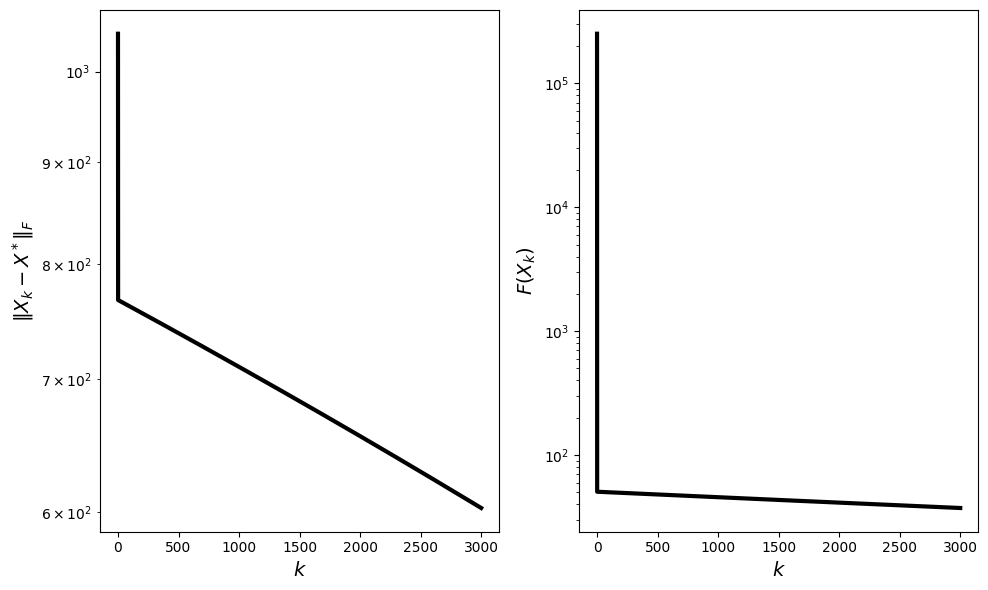

In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
ax1.plot(range(x_norms.shape[0]), x_norms, '-', c='black', lw=3)
ax2.plot(range(len(f_vals)), f_vals, '-', c='black', lw=3)

ax1.set_xlabel("$k$", fontsize=14)
ax1.set_ylabel("$\| X_k - X^* \|_F$", fontsize=14)
ax1.set_yscale("log")
ax2.set_xlabel("$k$", fontsize=14)
ax2.set_ylabel("$F(X_k)$", fontsize=14)
ax2.set_yscale("log")
fig.tight_layout()

## FISTA
We can extend the algorithm by including an inertia term.

Let us implement the function
```
fista(X0, lam, gamma, max_iter)
```
where:
- `X0` is the initial guess.
- `lam` is the regularization parameter $\lambda$.
- `gamma` is the step-size $\gamma$.
- `max_iter` is the number of iterations.

Like the previous function, it should return:
- `X` the last iterate.
- `x_norms` the sequence $\|X_{k} - X^* \|_F$ for each iterate $X_k$.

In [68]:
def fista(X0, lam, gamma, max_iter):
  X = X0.copy()
  x_norms = np.zeros(max_iter)
  x_norms[0] = np.linalg.norm(X0.copy() - X_star, ord='fro')
  f_vals = [F(X, lam)]
  Y = X.copy()

  tk = 1
  alpha = 12

  for k in range(1, max_iter):
    # TODO: compute the inertia parameter
    tk_next = (1 + np.sqrt(1 + 4 * tk**2)) / 2
    beta = (tk - 1) / tk_next
    # TODO: implement the FISTA iteration
    X_next = prox(Y - gamma * grad_f(Y), gamma * lam)
    Y_next = X_next + beta * (X_next - X)

    f_vals.append(F(X_next, lam))
    x_norms[k] = np.linalg.norm(X.copy() - X_star, ord='fro')
    X = X_next
    Y = Y_next
    tk = tk_next

  return X, x_norms, f_vals


Let us run FISTA with the same parameters as ISTA (stepsize and $\lambda$)

In [69]:
# TODO: run FISTA
X_fist, x_fista_norms, f_fista_vals = fista(x0, lam, gamma, max_iter)

/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_42902/754532012.py:6: RuntimeWarning: divide by zero encountered in matmul
  return U @ S @ Vt
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_42902/754532012.py:6: RuntimeWarning: overflow encountered in matmul
  return U @ S @ Vt
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_42902/754532012.py:6: RuntimeWarning: invalid value encountered in matmul
  return U @ S @ Vt


Let us now compare the result obtained from FISTA with the one obtained from ISTA

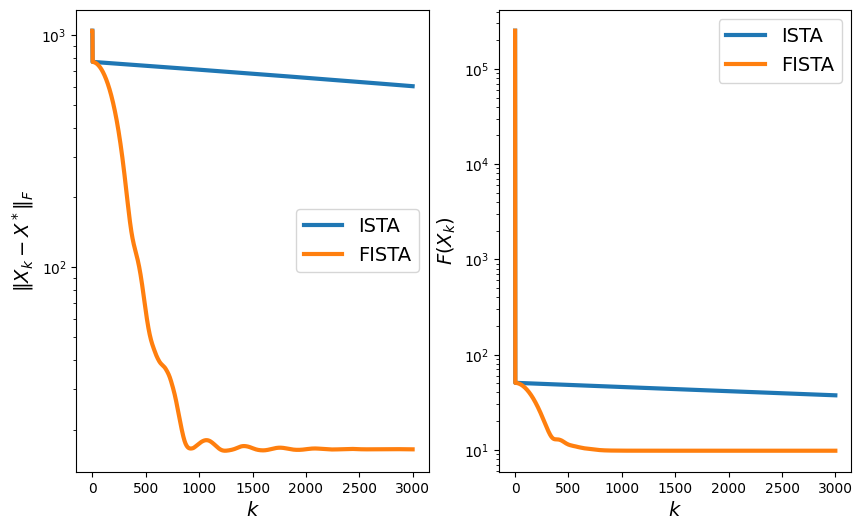

In [70]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
ax1.plot(range(x_norms.shape[0]), x_norms, '-', lw=3, label='ISTA')
ax1.plot(range(x_fista_norms.shape[0]), x_fista_norms, '-', lw=3, label='FISTA')

ax2.plot(range(len(f_vals)), f_vals, '-', lw=3, label='ISTA')
ax2.plot(range(len(f_fista_vals)), f_fista_vals, '-', lw=3, label='FISTA')

ax2.set_xlabel("$k$", fontsize=14)
ax2.set_ylabel("$F(X_k)$", fontsize=14)
ax2.set_yscale("log")
ax2.legend(fontsize=14)

ax1.set_xlabel("$k$", fontsize=14)
ax1.set_ylabel("$\| X_k - X^* \|_F$", fontsize=14)
ax1.set_yscale("log")
ax1.legend(fontsize=14)

Let us now define a list of (plausible) values for $\lambda$ and run the algorithm with those values

In [71]:
gamma = 1.0
X0 = np.full((d, d), 10.0)
norms = []
ratios = []
max_iter = 3000

lams = [10.0, 1.0, 0.1, 0.01]

for lam in lams:
  print("lambda = {}".format(lam))
  # TODO: run the algorithm for the different values of lambda
  _, _, x_norms, f_vals = fb(X0, lam, gamma, max_iter)
  norms.append(x_norms)

lambda = 10.0


/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_42902/754532012.py:6: RuntimeWarning: divide by zero encountered in matmul
  return U @ S @ Vt
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_42902/754532012.py:6: RuntimeWarning: overflow encountered in matmul
  return U @ S @ Vt
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_42902/754532012.py:6: RuntimeWarning: invalid value encountered in matmul
  return U @ S @ Vt


lambda = 1.0
lambda = 0.1
lambda = 0.01


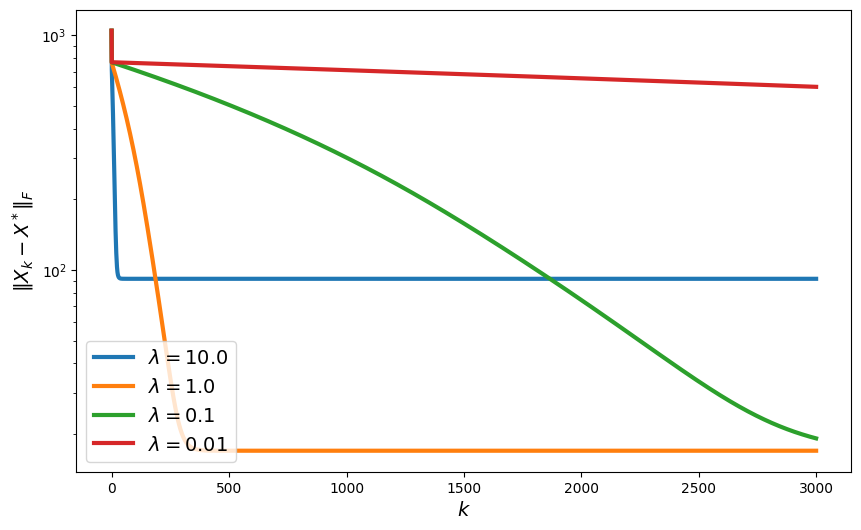

In [72]:
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(len(lams)):
  ax.plot(range(len(norms[i])), norms[i], '-', lw = 3, label="$\lambda = {}$".format(lams[i]))
ax.legend(fontsize=14)
ax.set_xlabel("$k$",fontsize=14)
ax.set_ylabel("$\| X_k - X^* \|_F$",fontsize=14)
ax.set_yscale('log')


Let us repeat the same procedure for FISTA

In [73]:
fista_norms = []
fista_ratios = []


for lam in lams:
  print("lambda = {}".format(lam))
  # TODO: run the algorithm con lambda = lam
  _, x_fista_norms, f_fista_vals = fista(X0, lam, gamma, max_iter)
  fista_norms.append(x_fista_norms)


lambda = 10.0


/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_42902/754532012.py:6: RuntimeWarning: divide by zero encountered in matmul
  return U @ S @ Vt
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_42902/754532012.py:6: RuntimeWarning: overflow encountered in matmul
  return U @ S @ Vt
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_42902/754532012.py:6: RuntimeWarning: invalid value encountered in matmul
  return U @ S @ Vt


lambda = 1.0
lambda = 0.1
lambda = 0.01


Let us plot the results

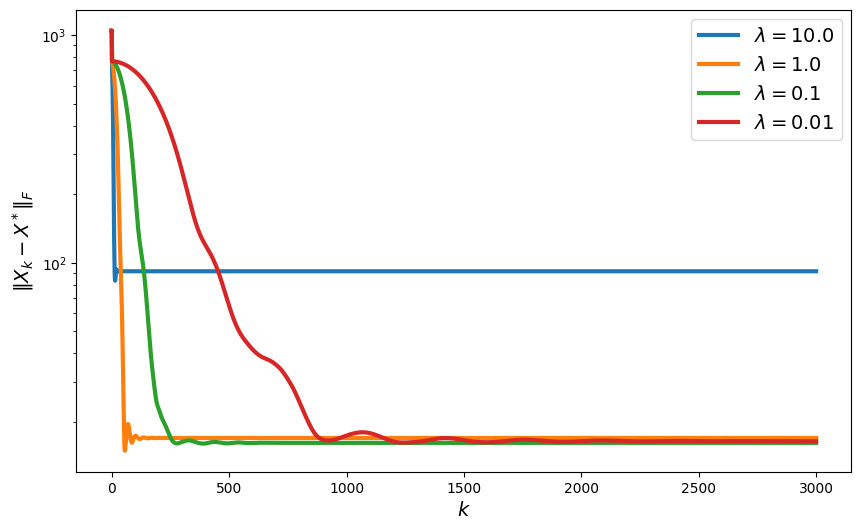

In [74]:
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(len(lams)):
  ax.plot(range(len(fista_norms[i])), fista_norms[i], '-', lw = 3, label="$\lambda = {}$".format(lams[i]))
ax.legend(fontsize=14)
ax.set_xlabel("$k$",fontsize=14)
ax.set_ylabel("$\| X_k - X^* \|_F$",fontsize=14)
ax.set_yscale('log')
